# Gamma–beta–epsilon server-results analysis

This notebook reads the merged `results.json` produced by `experiment_runner.py` and creates three figure families:

1. Mean final **core violation count** over physical-MDP seeds on the $(\epsilon, \beta)$ grid, one panel per $\gamma$, with the exact analytical $m=0$ curve.
2. For every $\gamma$ where one exists, an automatically selected fixed `(mdp_seed, beta)` whose final violation status changes with $\epsilon$, with upper and lower performance bounds plotted against $\epsilon$.
3. Mean upper performance bound over physical-MDP seeds on the same grid, one panel per $\gamma$.

Only successful runs are plotted. The notebook reports incomplete seed coverage, so it can also be used while a server experiment is still running.

## Configuration

By default, the notebook looks for the full experiment under `experiment_runs/gamma_beta_epsilon_g3_d70_d60_p8/results.json`. Edit `RESULTS_PATH`, or set the environment variable `REMOTE_POMDP_RESULTS`, if the retrieved file is elsewhere.

In [9]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.lines import Line2D

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "experiment_runner.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate the RemotePOMDP project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
DEFAULT_RESULTS_PATH = (
    PROJECT_ROOT
    / "experiment_runs"
    / "gamma_beta_epsilon_g3_d70_d60_p8"
    / "results.json"
)
RESULTS_PATH = Path(os.environ.get("REMOTE_POMDP_RESULTS", DEFAULT_RESULTS_PATH))
if not RESULTS_PATH.is_absolute():
    RESULTS_PATH = PROJECT_ROOT / RESULTS_PATH
RESULTS_PATH = RESULTS_PATH.resolve()

EXPECTED_MDP_SEEDS = 10
SAVE_FIGURES = False
FIGURE_DIR = PROJECT_ROOT / "experiments" / "gamma_beta_epsilon_analysis" / "figures"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results file: {RESULTS_PATH}")

Project root: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP
Results file: /Users/rplanchon/Documents/Etudes/MVA/Stage/Imperial/work/RemotePOMDP/experiment_runs/gamma_beta_epsilon_g3_d70_d60_p8/results.json


## Load and validate the merged results

If more than one initialization run exists for the same `(gamma, beta, epsilon, mdp_seed)`, it is first averaged within that seed. Every physical-MDP seed therefore receives equal weight in the final averages.

In [10]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"No merged results file at {RESULTS_PATH}.\n"
        "Retrieve it from the server, edit RESULTS_PATH, or set "
        "REMOTE_POMDP_RESULTS before starting Jupyter."
    )

payload = json.loads(RESULTS_PATH.read_text(encoding="utf-8"))
raw_runs = pd.json_normalize(payload.get("runs", []), sep=".")
if raw_runs.empty:
    raise ValueError("The results file contains no run records.")
if "status" not in raw_runs:
    raise ValueError("Every run record must contain a status field.")

runs = raw_runs.loc[raw_runs["status"].eq("ok")].copy()
if runs.empty:
    raise ValueError("The results file contains no successful runs.")

# Compatibility with the earlier notebook-generated result files.
legacy_aliases = {
    "objective": "performance.upper_bound",
    "lower_bound_objective": "performance.lower_bound",
}
for old_name, new_name in legacy_aliases.items():
    if new_name not in runs and old_name in runs:
        runs[new_name] = runs[old_name]

required_columns = [
    "gamma",
    "beta",
    "epsilon",
    "mdp_seed",
    "core_violation_count",
    "performance.upper_bound",
    "performance.lower_bound",
]
missing_columns = [name for name in required_columns if name not in runs]
if missing_columns:
    raise ValueError(f"Missing required result columns: {missing_columns}")

numeric_columns = [
    "gamma",
    "beta",
    "epsilon",
    "mdp_seed",
    "core_violation_count",
    "performance.upper_bound",
    "performance.lower_bound",
]
runs[numeric_columns] = runs[numeric_columns].apply(pd.to_numeric, errors="coerce")
invalid_key_rows = runs[["gamma", "beta", "epsilon", "mdp_seed"]].isna().any(axis=1)
if invalid_key_rows.any():
    warnings.warn(f"Dropping {int(invalid_key_rows.sum())} runs with invalid grid coordinates.")
    runs = runs.loc[~invalid_key_rows].copy()

seed_keys = ["gamma", "beta", "epsilon", "mdp_seed"]
seed_runs = (
    runs.groupby(seed_keys, as_index=False, dropna=False)
    .agg(
        core_violation_count=("core_violation_count", "mean"),
        upper_bound=("performance.upper_bound", "mean"),
        lower_bound=("performance.lower_bound", "mean"),
        initialization_runs=("status", "size"),
    )
    .sort_values(seed_keys)
    .reset_index(drop=True)
)

coverage = (
    seed_runs.groupby(["gamma", "beta", "epsilon"], as_index=False)
    .agg(mdp_seed_count=("mdp_seed", "nunique"))
)
incomplete = coverage.loc[coverage["mdp_seed_count"].ne(EXPECTED_MDP_SEEDS)]
if not incomplete.empty:
    warnings.warn(
        f"{len(incomplete)} grid cells do not yet have exactly "
        f"{EXPECTED_MDP_SEEDS} distinct MDP seeds. Averages use available seeds."
    )

summary = payload.get("summary", {})
print(
    f"Experiment: {payload.get('name', RESULTS_PATH.parent.name)}\n"
    f"Successful records loaded: {len(runs):,}\n"
    f"Seed-level records: {len(seed_runs):,}\n"
    f"Gammas: {sorted(seed_runs['gamma'].unique())}\n"
    f"Merged completion: {summary.get('ok', len(runs))}/{summary.get('expected', '?')} successful"
)
display(coverage["mdp_seed_count"].describe().to_frame("seed coverage per grid cell"))

Experiment: gamma_beta_epsilon_g3_d70_d60_p8
Successful records loaded: 3,000
Seed-level records: 3,000
Gammas: [np.float64(0.8), np.float64(0.9), np.float64(0.95)]
Merged completion: 3000/3000 successful


,seed coverage per grid cell
count,300.0
mean,10.0
std,0.0
min,10.0
25%,10.0
50%,10.0
75%,10.0
max,10.0


In [11]:
def make_panel_figure(values: list[float], *, panel_width: float = 4.2):
    n_panels = len(values)
    fig, axes = plt.subplots(
        1,
        n_panels,
        figsize=(panel_width * n_panels, 4.3),
        squeeze=False,
        layout="constrained",
    )
    return fig, axes.ravel()

def save_figure(fig: plt.Figure, stem: str) -> None:
    if not SAVE_FIGURES:
        return
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURE_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

gammas = sorted(seed_runs["gamma"].unique())
epsilons = np.sort(seed_runs["epsilon"].unique())
betas = np.sort(seed_runs["beta"].unique())

print(f"Grid dimensions: {len(gammas)} gamma × {len(betas)} beta × {len(epsilons)} epsilon")

Grid dimensions: 3 gamma × 10 beta × 10 epsilon


## Figure 1 — Mean core violation count

Each point is one sampled $(\epsilon, \beta)$ location. White points have zero final core violations on average; darker points have more. A missing run combination has no point. The black curve is $m=0$, where

$$m = \beta - \frac{\gamma\epsilon(1-\epsilon)}{1-\gamma},$$

The black line is the exact analytical curve $\beta=\gamma\epsilon(1-\epsilon)/(1-\gamma)$, evaluated on a dense epsilon grid.

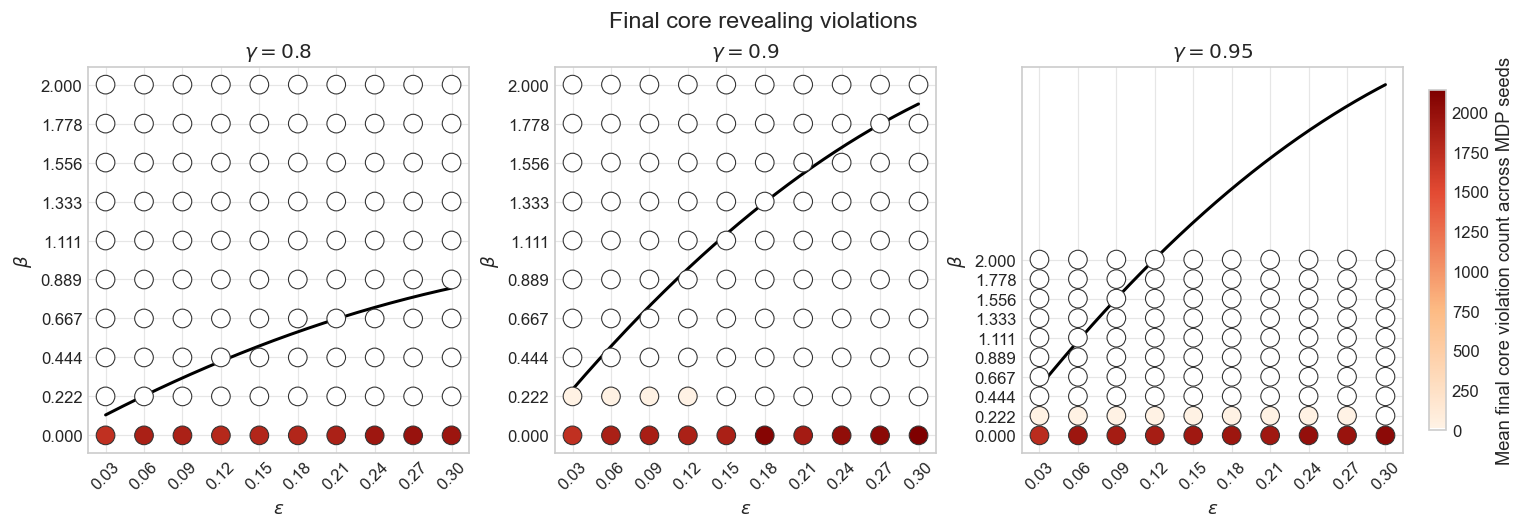

In [12]:
mean_violations = (
    seed_runs.groupby(["gamma", "beta", "epsilon"], as_index=False)
    .agg(
        mean_core_violations=("core_violation_count", "mean"),
        mdp_seed_count=("mdp_seed", "nunique"),
    )
)

violation_cmap = LinearSegmentedColormap.from_list(
    "zero_white_to_red",
    [
        (0.0, "#ffffff"),
        (0.000001, "#fff3e6"),
        (0.35, "#fdbb84"),
        (0.70, "#e34a33"),
        (1.0, "#7f0000"),
    ],
)
violation_cmap.set_bad("#d9d9d9")
violation_vmax = float(mean_violations["mean_core_violations"].max())
violation_norm = Normalize(vmin=0.0, vmax=max(violation_vmax, 1e-12))

fig, axes = make_panel_figure(gammas)
plot_artist = None
for ax, gamma in zip(axes, gammas):
    panel = mean_violations.loc[mean_violations["gamma"].eq(gamma)]
    plot_artist = ax.scatter(
        panel["epsilon"],
        panel["beta"],
        c=panel["mean_core_violations"],
        cmap=violation_cmap,
        norm=violation_norm,
        marker="o",
        s=125,
        edgecolors="#333333",
        linewidths=0.65,
        zorder=3,
    )

    if not np.isclose(gamma, 1.0):
        epsilon_curve = np.linspace(
            epsilons.min(),
            epsilons.max(),
            500,
        )
        beta_curve = gamma * epsilon_curve * (1.0 - epsilon_curve) / (1.0 - gamma)
        ax.plot(epsilon_curve, beta_curve, color="black", linewidth=1.8)

    ax.set_title(rf"$\gamma={gamma:g}$")
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$\beta$")
    ax.set_xticks(epsilons)
    ax.set_yticks(betas)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, color="#e6e6e6", linewidth=0.7, zorder=0)

if plot_artist is not None:
    colorbar = fig.colorbar(plot_artist, ax=axes.tolist(), shrink=0.88, pad=0.02)
    colorbar.set_label("Mean final core violation count across MDP seeds")
fig.suptitle("Final core revealing violations", fontsize=14)
save_figure(fig, "mean_core_violations")
plt.show()

## Figure 2 — Bound curves across a violation-status transition

For each gamma, the selection below searches fixed `(mdp_seed, beta)` groups and keeps those containing both zero-violation and positive-violation epsilon values. It prioritizes complete epsilon coverage, a balanced number of both statuses, and then a large observed violation count.

A lower bound is only computed and stored for runs with core violations, so gaps in the lower-bound curve at zero-violation epsilon values are expected. Marker color reports violation status: green means zero and red means positive.

In [13]:
candidate_cases = (
    seed_runs.groupby(["gamma", "mdp_seed", "beta"], as_index=False)
    .agg(
        epsilon_count=("epsilon", "nunique"),
        zero_count=("core_violation_count", lambda values: int((values <= 0).sum())),
        violating_count=("core_violation_count", lambda values: int((values > 0).sum())),
        max_violation_count=("core_violation_count", "max"),
    )
)
candidate_cases = candidate_cases.loc[
    candidate_cases["zero_count"].gt(0) & candidate_cases["violating_count"].gt(0)
].copy()
candidate_cases["status_balance"] = candidate_cases[["zero_count", "violating_count"]].min(axis=1)
candidate_cases = candidate_cases.sort_values(
    ["gamma", "epsilon_count", "status_balance", "max_violation_count", "mdp_seed", "beta"],
    ascending=[True, False, False, False, True, True],
)
selected_cases = candidate_cases.groupby("gamma", as_index=False).head(1).reset_index(drop=True)

if selected_cases.empty:
    print("No fixed (mdp_seed, beta) case changes violation status across epsilon.")
else:
    display(
        selected_cases[[
            "gamma",
            "mdp_seed",
            "beta",
            "epsilon_count",
            "zero_count",
            "violating_count",
            "max_violation_count",
        ]]
    )

,gamma,mdp_seed,beta,epsilon_count,zero_count,violating_count,max_violation_count
0,0.90,3,0.222222,10,6,4,185.0
1,0.95,3,0.222222,10,1,9,235.0


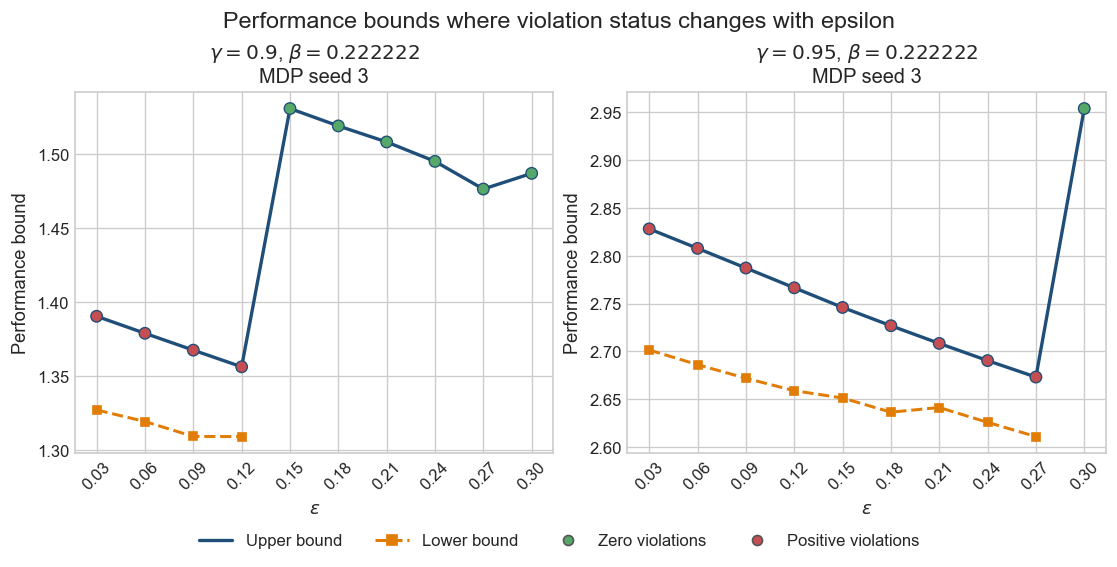

In [14]:
if not selected_cases.empty:
    selected_gammas = selected_cases["gamma"].tolist()
    fig, axes = make_panel_figure(selected_gammas, panel_width=4.6)

    for ax, selected in zip(axes, selected_cases.itertuples(index=False)):
        case = seed_runs.loc[
            seed_runs["gamma"].eq(selected.gamma)
            & seed_runs["mdp_seed"].eq(selected.mdp_seed)
            & seed_runs["beta"].eq(selected.beta)
        ].sort_values("epsilon")
        status_colors = np.where(case["core_violation_count"].gt(0), "#c44e52", "#55a868")

        ax.plot(
            case["epsilon"],
            case["upper_bound"],
            color="#1f4e79",
            linewidth=2.0,
            label="Upper bound",
            zorder=2,
        )
        ax.scatter(
            case["epsilon"],
            case["upper_bound"],
            c=status_colors,
            edgecolor="#1f4e79",
            linewidth=0.8,
            s=48,
            zorder=3,
        )
        ax.plot(
            case["epsilon"],
            case["lower_bound"],
            color="#e17c05",
            linestyle="--",
            marker="s",
            markersize=5,
            linewidth=1.8,
            label="Lower bound",
            zorder=2,
        )

        ax.set_title(
            rf"$\gamma={selected.gamma:g}$, $\beta={selected.beta:g}$"
            + f"\nMDP seed {int(selected.mdp_seed)}"
        )
        ax.set_xlabel(r"$\epsilon$")
        ax.set_ylabel("Performance bound")
        ax.set_xticks(case["epsilon"].to_numpy())
        ax.tick_params(axis="x", rotation=45)

    legend_handles = [
        Line2D([0], [0], color="#1f4e79", lw=2, label="Upper bound"),
        Line2D([0], [0], color="#e17c05", lw=1.8, ls="--", marker="s", label="Lower bound"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#55a868", markeredgecolor="#555555", label="Zero violations"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#c44e52", markeredgecolor="#555555", label="Positive violations"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=4)
    fig.suptitle("Performance bounds where violation status changes with epsilon", fontsize=14)
    save_figure(fig, "bounds_across_violation_transition")
    plt.show()

## Figure 3 — Mean upper bound

Each point is the unweighted mean of the upper performance bound over physical-MDP seeds at one sampled $(\epsilon, \beta)$ location. All gamma panels share one color scale, enabling direct comparison across panels. Missing run combinations have no point.

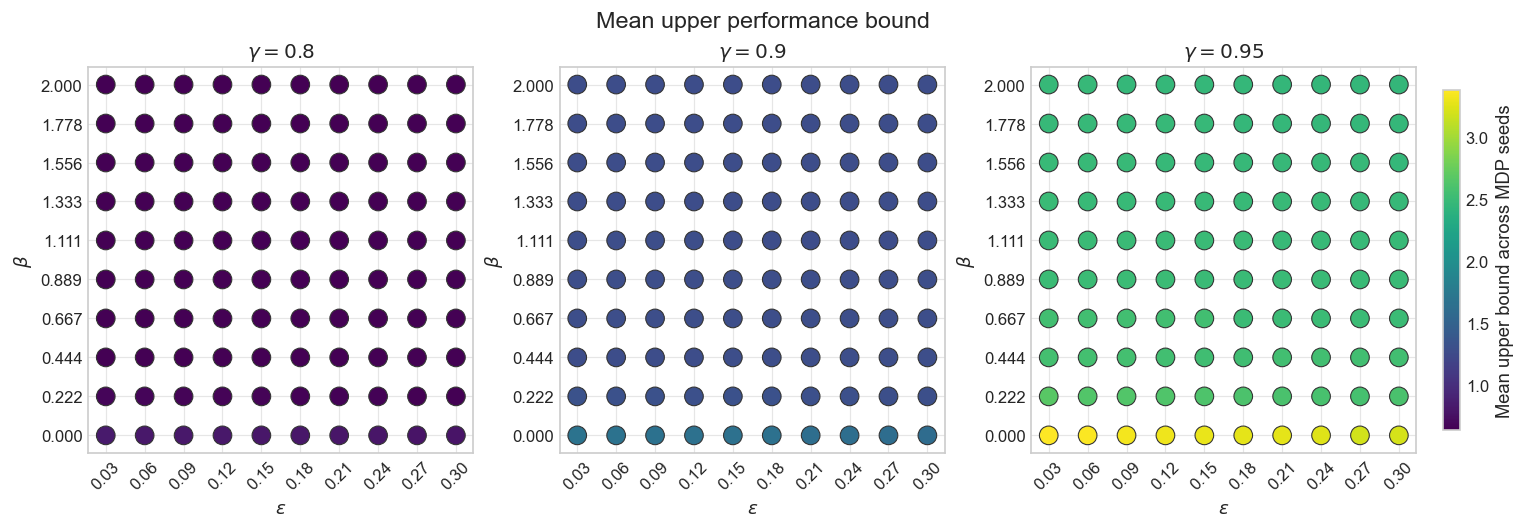

In [15]:
mean_upper_bounds = (
    seed_runs.groupby(["gamma", "beta", "epsilon"], as_index=False)
    .agg(
        mean_upper_bound=("upper_bound", "mean"),
        mdp_seed_count=("mdp_seed", "nunique"),
    )
)
upper_min = float(mean_upper_bounds["mean_upper_bound"].min())
upper_max = float(mean_upper_bounds["mean_upper_bound"].max())
if np.isclose(upper_min, upper_max):
    upper_max = upper_min + 1e-12
upper_norm = Normalize(vmin=upper_min, vmax=upper_max)
upper_cmap = plt.colormaps["viridis"].copy()
upper_cmap.set_bad("#d9d9d9")

fig, axes = make_panel_figure(gammas)
plot_artist = None
for ax, gamma in zip(axes, gammas):
    panel = mean_upper_bounds.loc[mean_upper_bounds["gamma"].eq(gamma)]
    plot_artist = ax.scatter(
        panel["epsilon"],
        panel["beta"],
        c=panel["mean_upper_bound"],
        cmap=upper_cmap,
        norm=upper_norm,
        marker="o",
        s=125,
        edgecolors="#333333",
        linewidths=0.65,
        zorder=3,
    )
    ax.set_title(rf"$\gamma={gamma:g}$")
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$\beta$")
    ax.set_xticks(epsilons)
    ax.set_yticks(betas)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, color="#e6e6e6", linewidth=0.7, zorder=0)

if plot_artist is not None:
    colorbar = fig.colorbar(plot_artist, ax=axes.tolist(), shrink=0.88, pad=0.02)
    colorbar.set_label("Mean upper bound across MDP seeds")
fig.suptitle("Mean upper performance bound", fontsize=14)
save_figure(fig, "mean_upper_bound")
plt.show()

## Selected-case data

The final cell prints the exact records used in Figure 2 for reproducibility.

In [16]:
if not selected_cases.empty:
    selected_records = []
    for selected in selected_cases.itertuples(index=False):
        selected_records.append(
            seed_runs.loc[
                seed_runs["gamma"].eq(selected.gamma)
                & seed_runs["mdp_seed"].eq(selected.mdp_seed)
                & seed_runs["beta"].eq(selected.beta),
                [
                    "gamma",
                    "mdp_seed",
                    "beta",
                    "epsilon",
                    "core_violation_count",
                    "upper_bound",
                    "lower_bound",
                ],
            ]
        )
    display(pd.concat(selected_records, ignore_index=True).sort_values(["gamma", "epsilon"]))

,gamma,mdp_seed,beta,epsilon,core_violation_count,upper_bound,lower_bound
0,0.90,3,0.222222,0.03,185.0,1.390497,1.327283
1,0.90,3,0.222222,0.06,178.0,1.379011,1.319491
2,0.90,3,0.222222,0.09,169.0,1.367637,1.309379
3,0.90,3,0.222222,0.12,157.0,1.356398,1.309330
4,0.90,3,0.222222,0.15,0.0,1.530669,NaN
5,0.90,3,0.222222,0.18,0.0,1.518946,NaN
6,0.90,3,0.222222,0.21,0.0,1.508124,NaN
7,0.90,3,0.222222,0.24,0.0,1.495024,NaN
8,0.90,3,0.222222,0.27,0.0,1.476352,NaN
9,0.90,3,0.222222,0.30,0.0,1.486936,NaN
